## Polynomial Curve Fitting: Training Data Visualization

In this hands-on example, we start with a simple regression problem.  
Suppose we observe an input variable **x** and want to predict the value of a target variable **t**.

To demonstrate this idea, we generate a small synthetic dataset. The data is created from the underlying function

$$ t = \sin(2\pi x) $$

However, in real-world data, observations often contain **noise**. Therefore, we add small random Gaussian noise to the target values.

In the plot below:

- **Blue circles** represent the training data points.
- **Green curve** represents the true function $ \sin(2\pi x) $ that generated the data.
- We assume that the true function is **unknown**, and our goal will later be to **approximate it using polynomial curve fitting**.

This dataset will be used in the following sections to study:
- polynomial regression
- model complexity
- overfitting
- regularization.

The goal of the learning algorithm is to predict the value of **t** for a new input **x**, using only the observed training data.

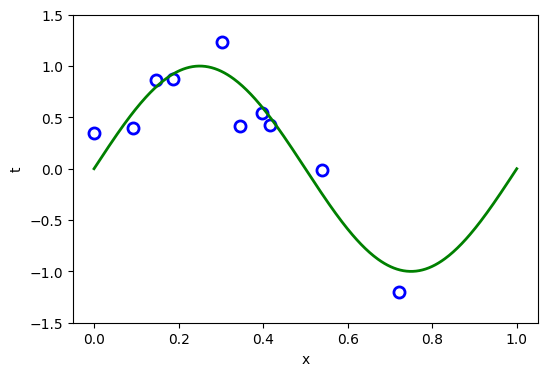

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(1)

# Number of training points
N = 10

# Randomly sample x in [0,1]
x = np.random.uniform(0,1,N)

# Sort for nicer visualization
x = np.sort(x)

# True function
y_true = np.sin(2*np.pi*x)

# Add Gaussian noise
noise = np.random.normal(0,0.2,N)
t = y_true + noise

# Smooth curve for true function
x_curve = np.linspace(0,1,400)
y_curve = np.sin(2*np.pi*x_curve)

# Plot
plt.figure(figsize=(6,4))

# Training points (blue open circles)
plt.plot(x, t, 'o', markerfacecolor='none',
         markeredgecolor='blue', markersize=8, markeredgewidth=2)

# True function
plt.plot(x_curve, y_curve, color='green', linewidth=2)

# Labels
plt.xlabel('x')
plt.ylabel('t')

# Axis limits (so curve does not touch borders)
plt.xlim(-0.05,1.05)
plt.ylim(-1.5,1.5)

plt.show()

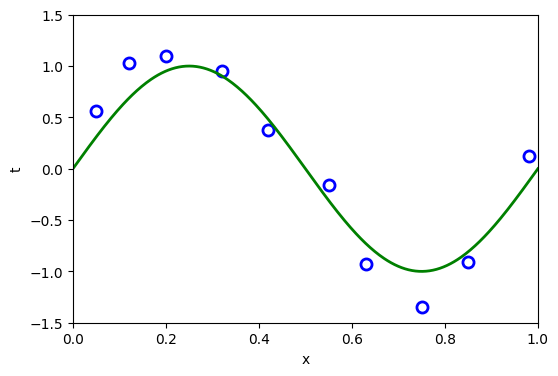

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Training data points (chosen to resemble the book figure)
x = np.array([0.05, 0.12, 0.20, 0.32, 0.42, 0.55, 0.63, 0.75, 0.85, 0.98])
t = np.sin(2*np.pi*x) + np.array([0.25,0.35,0.15,0.05,-0.1,0.15,-0.2,-0.35,-0.1,0.25])

# True function
x_curve = np.linspace(0,1,400)
y_curve = np.sin(2*np.pi*x_curve)

# Plot
plt.figure(figsize=(6,4))

# Training data (blue hollow circles)
plt.plot(x, t, 'o', markerfacecolor='none',
         markeredgecolor='blue', markersize=8, markeredgewidth=2)

# True function
plt.plot(x_curve, y_curve, color='green', linewidth=2)

# Labels
plt.xlabel('x')
plt.ylabel('t')

# Domain limits like the figure
plt.xlim(0,1)
plt.ylim(-1.5,1.5)

plt.show()

## Illustration of the Error Function

In polynomial curve fitting, we measure how well the model fits the training data using an **error function**.

A commonly used error function is the **sum-of-squares error**

$$ E(w) = \frac{1}{2}\sum_{n=1}^{N}(y(x_n,w) - t_n)^2 $$

Here:

- $t_n$ represents the **true target value** for the data point.
- $y(x_n,w)$ represents the **model prediction**.
- The **difference between them** is called the **residual error**.

In the plot below:

- **Blue circles** represent the true data values $t_n$.
- **Green points** represent the predicted values $y(x_n,w)$.
- **Vertical green lines** represent the error (difference between prediction and target).
- The **red curve** represents the model function $y(x,w)$.

The total error is obtained by **squaring these vertical distances and summing them for all data points**.

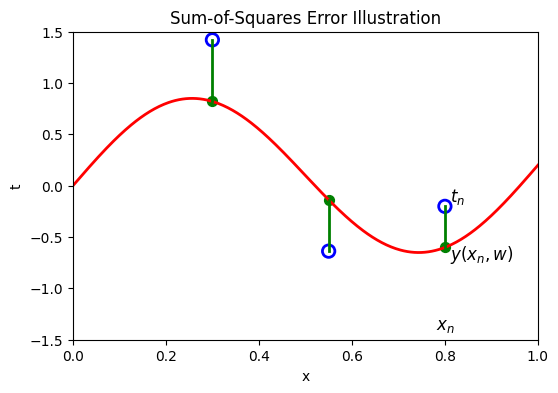

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Model curve
x_curve = np.linspace(0, 1, 400)
y_curve = 0.8*np.sin(2*np.pi*x_curve) + 0.2*x_curve

# Data locations (x_n)
x = np.array([0.3, 0.55, 0.8])

# Model prediction y(x_n,w)
y_pred = 0.8*np.sin(2*np.pi*x) + 0.2*x

# Target values t_n
t = y_pred + np.array([0.6, -0.5, 0.4])

plt.figure(figsize=(6,4))

# Plot model curve
plt.plot(x_curve, y_curve, color='red', linewidth=2)

# Predicted points
plt.scatter(x, y_pred, color='green', s=50)

# True target points
plt.scatter(x, t, facecolors='none', edgecolors='blue', s=80, linewidths=2)

# Vertical error bars
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y_pred[i], t[i]], color='green', linewidth=2)

# Label t_n (top blue point)
plt.text(x[2]+0.01, t[2]+0.05, r'$t_n$', fontsize=12)

# Label prediction
plt.text(x[2]+0.01, y_pred[2]-0.12, r'$y(x_n,w)$', fontsize=12)

# Label x_n directly below the same vertical line
plt.text(x[2]-0.02, -1.4, r'$x_n$', fontsize=12)

plt.xlabel('x')
plt.ylabel('t')

plt.xlim(0,1)
plt.ylim(-1.5,1.5)

plt.title("Sum-of-Squares Error Illustration")

plt.show()

## Polynomial Curve Fitting (Figure 1.4)

This figure demonstrates polynomial curve fitting for different model orders $M$.

We are given a training dataset consisting of pairs $(x_n, t_n)$, where:

- $x_n$ is the input variable.
- $t_n$ is the corresponding target value.

The true underlying function is:

$$ t = \sin(2\pi x) $$

However, the observed data contains small noise.

A polynomial model of order $M$ is used:

$$ y(x,w) = w_0 + w_1x + w_2x^2 + \dots + w_M x^M $$

The parameters $w$ are estimated by minimizing the **sum-of-squares error**

$$ E(w) = \frac{1}{2}\sum_{n=1}^{N}(y(x_n,w)-t_n)^2 $$

The four subplots illustrate the effect of model complexity:

- **M = 0:** The model is too simple and cannot capture the structure of the data.
- **M = 1:** A straight line provides a slightly better approximation.
- **M = 3:** The model captures the underlying trend reasonably well.
- **M = 9:** The model becomes overly flexible and fits the noise, leading to overfitting.

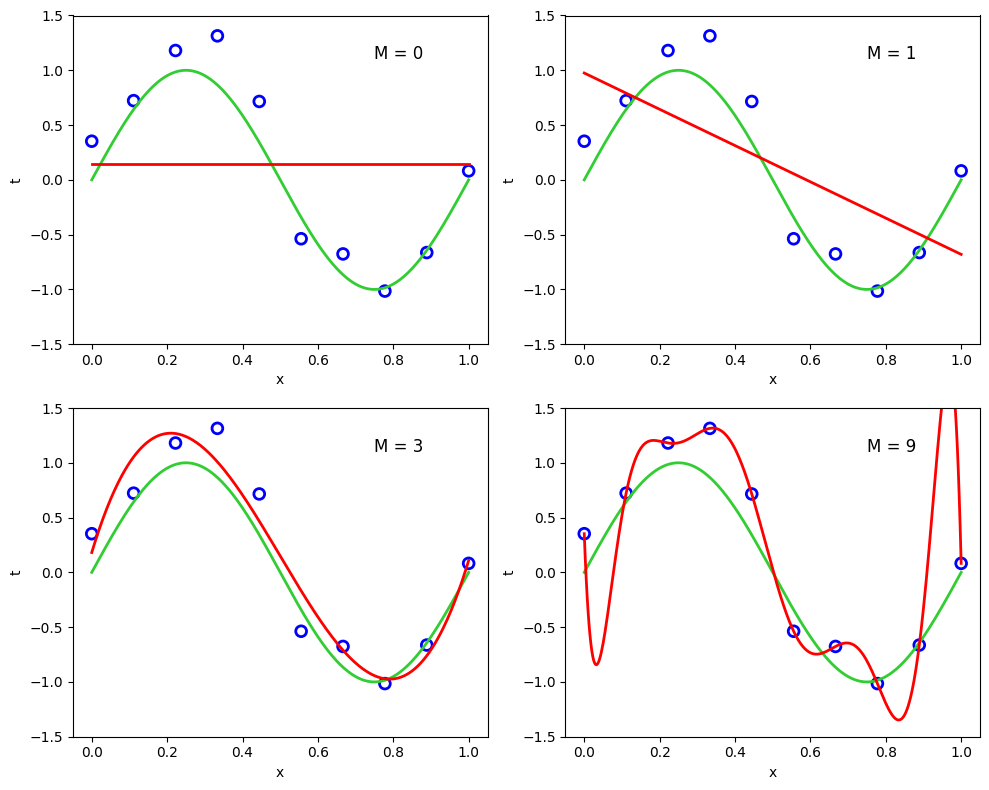

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Generate training data
np.random.seed(0)

N = 10
x = np.linspace(0,1,N)
t = np.sin(2*np.pi*x) + np.random.normal(0,0.2,N)

# True function
x_true = np.linspace(0,1,400)
t_true = np.sin(2*np.pi*x_true)

# Polynomial orders
M_values = [0,1,3,9]

plt.figure(figsize=(10,8))

for i,M in enumerate(M_values):

    # Polynomial fitting
    w = np.polyfit(x,t,M)
    y = np.polyval(w,x_true)

    plt.subplot(2,2,i+1)

    # True function
    plt.plot(x_true,t_true,color='limegreen',linewidth=2)

    # Polynomial fit
    plt.plot(x_true,y,color='red',linewidth=2)

    # Training points
    plt.scatter(x,t,facecolors='none',edgecolors='blue',s=60,linewidths=2)

    plt.text(0.75,1.1,f"M = {M}",fontsize=12)

    plt.xlabel("x")
    plt.ylabel("t")

    plt.xlim(-0.05,1.05)
    plt.ylim(-1.5,1.5)

plt.tight_layout()
plt.show()

## Root-Mean-Square Error vs Model Complexity

This figure illustrates how model complexity affects prediction performance.

For polynomial curve fitting, the model is written as

$$ y(x,w) = w_0 + w_1x + w_2x^2 + \dots + w_M x^M $$

where $M$ is the order of the polynomial.

To evaluate the model performance, we compute the **root-mean-square (RMS) error**

$$ E_{RMS} = \sqrt{\frac{2E(w)}{N}} $$

where

$$ E(w) = \frac{1}{2}\sum_{n=1}^{N}(y(x_n,w)-t_n)^2 $$

Here:

- $x_n$ : input data  
- $t_n$ : target value  
- $y(x_n,w)$ : model prediction  

The RMS error is computed for both:

- **Training dataset**
- **Independent test dataset**

### Interpretation of the Figure

- For **small polynomial order $M$**, the model is too simple and both errors are large.
- As **$M$ increases**, the model fits the training data better.
- For **very large $M$**, the model overfits the training data.
- Training error becomes very small, but **test error increases sharply**, indicating **overfitting**.

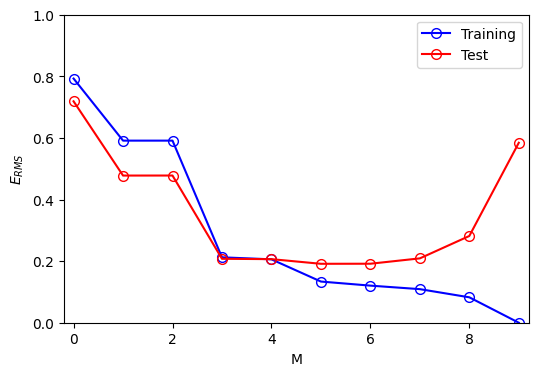

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Training data
N = 10
x_train = np.linspace(0,1,N)
t_train = np.sin(2*np.pi*x_train) + np.random.normal(0,0.2,N)

# Test data
x_test = np.linspace(0,1,100)
t_test = np.sin(2*np.pi*x_test)

# Polynomial degrees
M_values = np.arange(0,10)

train_error = []
test_error = []

for M in M_values:

    # Fit polynomial to training data
    w = np.polyfit(x_train, t_train, M)

    # Predictions
    y_train = np.polyval(w, x_train)
    y_test = np.polyval(w, x_test)

    # RMS error
    Erms_train = np.sqrt(np.mean((y_train - t_train)**2))
    Erms_test = np.sqrt(np.mean((y_test - t_test)**2))

    train_error.append(Erms_train)
    test_error.append(Erms_test)

plt.figure(figsize=(6,4))

plt.plot(M_values, train_error, 'o-', color='blue', label='Training', markerfacecolor='none', markersize=7)
plt.plot(M_values, test_error, 'o-', color='red', label='Test', markerfacecolor='none', markersize=7)

plt.xlabel("M")
plt.ylabel(r"$E_{RMS}$")

plt.xlim(-0.2,9.2)
plt.ylim(0,1)

plt.legend()

plt.show()

## Figure 1.6 — Effect of Dataset Size on Overfitting

This figure illustrates how increasing the number of training data points can mitigate the problem of overfitting.

We fit a high-order polynomial ($M=9$) to two different datasets:

*   **Left Plot:** $N=15$ data points.
*   **Right Plot:** $N=100$ data points.

Even with a complex model (high $M$), a larger dataset provides more constraints and reduces the model's ability to fit noise. The model becomes more stable and better captures the true underlying function, leading to improved generalization.

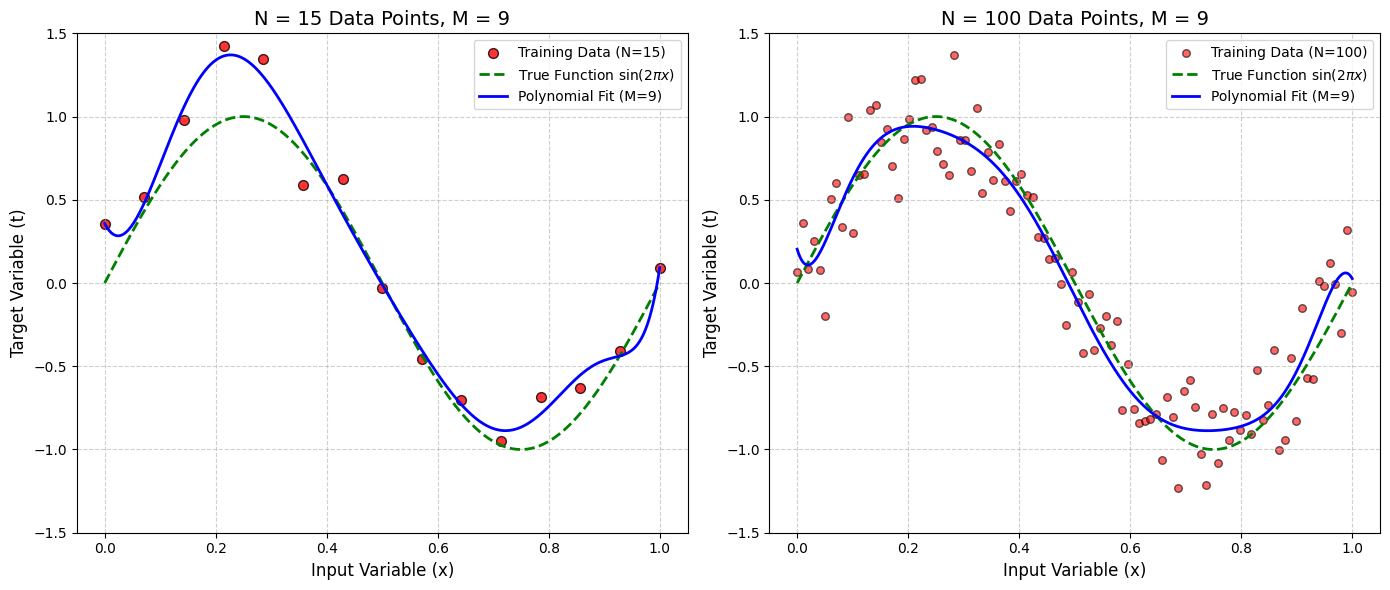

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0) # For reproducibility

# True function definition (assuming it's already defined or a global variable)
def true_function(x):
    return np.sin(2*np.pi*x)

# Data generation function (assuming it's already defined or a global variable)
def generate_data(N_points):
    x = np.linspace(0, 1, N_points)
    t = true_function(x) + np.random.normal(0, 0.2, N_points)
    return x, t

def polynomial_fit(x,t,M):
    X = np.vander(x,M+1,increasing=True)
    w = np.linalg.inv(X.T@X)@X.T@t
    return w

def predict(x,w):
    M = len(w)-1
    X = np.vander(x,M+1,increasing=True)
    return X@w


polynomial_order = 9

x_plot_smooth = np.linspace(0, 1, 400) # For smooth curve plotting
t_true_plot = true_function(x_plot_smooth)

plt.figure(figsize=(14, 6))

# --- First Subplot: N = 15 Data Points ---
plt.subplot(1, 2, 1)

N_15 = 15
x_train_15, t_train_15 = generate_data(N_15)

w_15 = polynomial_fit(x_train_15, t_train_15, polynomial_order)
y_fit_15 = predict(x_plot_smooth, w_15)

plt.scatter(x_train_15, t_train_15, label=f"Training Data (N={N_15})", color='red', marker='o', s=50, edgecolors='black', alpha=0.8)
plt.plot(x_plot_smooth, t_true_plot, 'g--', label=r"True Function $\sin(2\pi x)$", linewidth=2)
plt.plot(x_plot_smooth, y_fit_15, 'b-', label=f"Polynomial Fit (M={polynomial_order})", linewidth=2)

plt.title(f"N = {N_15} Data Points, M = {polynomial_order}", fontsize=14)
plt.xlabel("Input Variable (x)", fontsize=12)
plt.ylabel("Target Variable (t)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-1.5, 1.5)
plt.xlim(-0.05, 1.05)

# --- Second Subplot: N = 100 Data Points ---
plt.subplot(1, 2, 2)

N_100 = 100
x_train_100, t_train_100 = generate_data(N_100)

w_100 = polynomial_fit(x_train_100, t_train_100, polynomial_order)
y_fit_100 = predict(x_plot_smooth, w_100)

plt.scatter(x_train_100, t_train_100, label=f"Training Data (N={N_100})", color='red', marker='o', s=30, edgecolors='black', alpha=0.6)
plt.plot(x_plot_smooth, t_true_plot, 'g--', label=r"True Function $\sin(2\pi x)$", linewidth=2)
plt.plot(x_plot_smooth, y_fit_100, 'b-', label=f"Polynomial Fit (M={polynomial_order})", linewidth=2)

plt.title(f"N = {N_100} Data Points, M = {polynomial_order}", fontsize=14)
plt.xlabel("Input Variable (x)", fontsize=12)
plt.ylabel("Target Variable (t)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-1.5, 1.5)
plt.xlim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## Figure 1.7 — Effect of Regularization

This figure illustrates the impact of regularization on a high-order polynomial fit ($M=9$), demonstrating how it can mitigate overfitting. We use the regularized error function:

$$ E(w) = \frac{1}{2} \sum (y(x_n, w) - t_n)^2 + \frac{\lambda}{2} ||w||^2 $$

where $\lambda$ is the regularization parameter.

We will compare three scenarios for an $M=9$ polynomial fitted to the dataset:

*   **Left Plot:** Small regularization with $\ln \lambda = -18$ (i.e., $\lambda = e^{-18}$). This allows the model to fit the training data closely but with some smoothing.
*   **Middle Plot:** Moderate regularization with $\ln \lambda = 0$ (i.e., $\lambda = 1$). This significantly constrains the weights, leading to a smoother fit.
*   **Right Plot:** No regularization, i.e., $\lambda = 0$. This corresponds to the unregularized $M=9$ polynomial fit previously shown, which exhibits severe overfitting.

By comparing these plots, we can observe how increasing the regularization parameter $\lambda$ encourages smoother models and reduces the problem of overfitting, leading to better generalization.

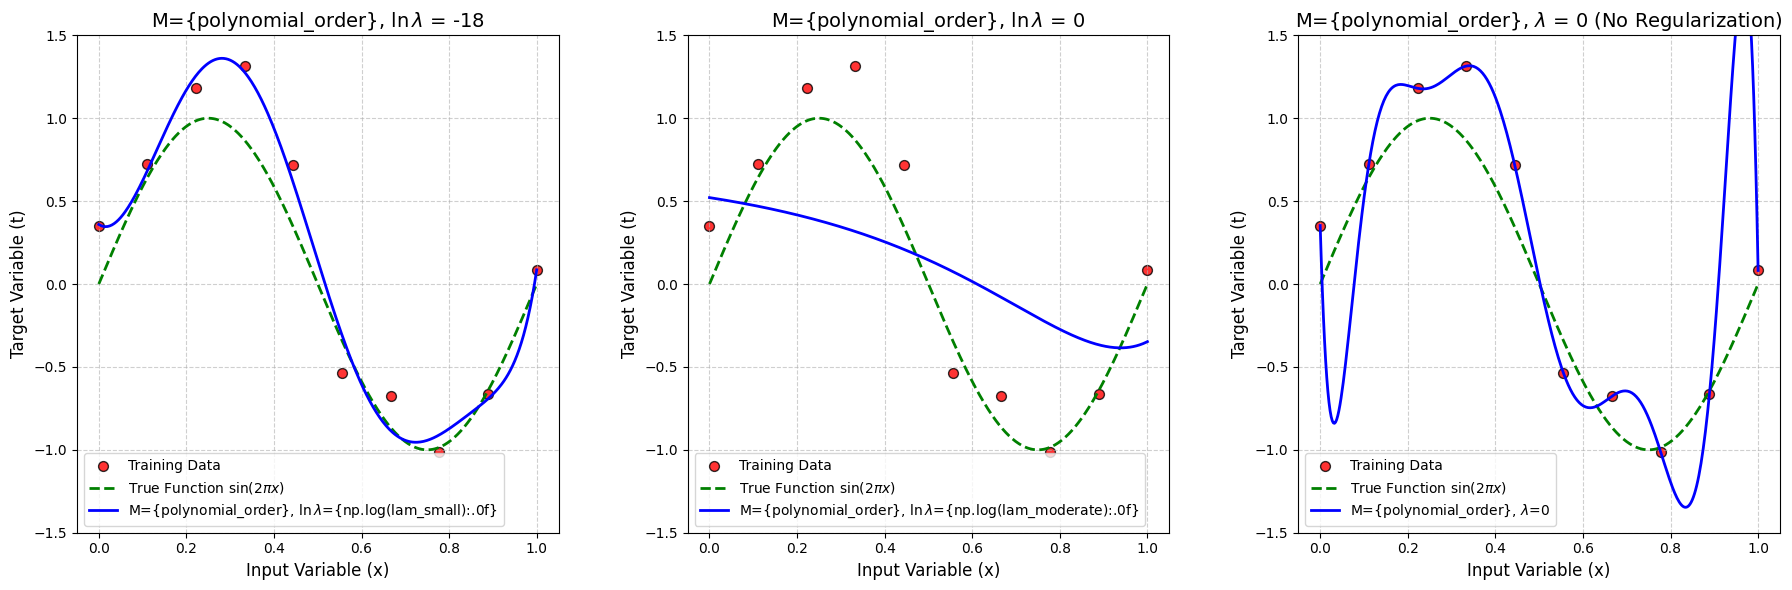

In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0) # For reproducibility

# Generate training data (N=10 from Figure 1.2/1.4)
x, t = generate_data(10)

# Points for plotting the true function and fitted curves
x_plot_smooth = np.linspace(0, 1, 400)
t_true_plot = true_function(x_plot_smooth)

polynomial_order = 9

plt.figure(figsize=(18, 6)) # Larger figure for three subplots

# --- Case 1: ln(lambda) = -18 (Small Regularization) ---
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
lam_small = np.exp(-18)
w_reg_small = ridge_fit(x, t, polynomial_order, lam_small)
y_fit_small = predict(x_plot_smooth, w_reg_small)

plt.scatter(x, t, label="Training Data", color='red', marker='o', s=50, edgecolors='black', alpha=0.8)
plt.plot(x_plot_smooth, t_true_plot, 'g--', label=r"True Function $\sin(2\pi x)$", linewidth=2)
plt.plot(x_plot_smooth, y_fit_small, 'b-', label=r"M={polynomial_order}, $\ln\lambda$={np.log(lam_small):.0f}", linewidth=2)

plt.title(r"M={polynomial_order}, $\ln\lambda$ = -18", fontsize=14)
plt.xlabel("Input Variable (x)", fontsize=12)
plt.ylabel("Target Variable (t)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-1.5, 1.5)
plt.xlim(-0.05, 1.05)

# --- Case 2: ln(lambda) = 0 (Moderate Regularization) ---
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
lam_moderate = np.exp(0) # lambda = 1
w_reg_moderate = ridge_fit(x, t, polynomial_order, lam_moderate)
y_fit_moderate = predict(x_plot_smooth, w_reg_moderate)

plt.scatter(x, t, label="Training Data", color='red', marker='o', s=50, edgecolors='black', alpha=0.8)
plt.plot(x_plot_smooth, t_true_plot, 'g--', label=r"True Function $\sin(2\pi x)$", linewidth=2)
plt.plot(x_plot_smooth, y_fit_moderate, 'b-', label=r"M={polynomial_order}, $\ln\lambda$={np.log(lam_moderate):.0f}", linewidth=2)

plt.title(r"M={polynomial_order}, $\ln\lambda$ = 0", fontsize=14)
plt.xlabel("Input Variable (x)", fontsize=12)
plt.ylabel("Target Variable (t)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-1.5, 1.5)
plt.xlim(-0.05, 1.05)

# --- Case 3: lambda = 0 (No Regularization, from Figure 1.4) ---
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot

# This is effectively the polynomial_fit without lambda
w_unreg = polynomial_fit(x, t, polynomial_order) # Use the non-regularized fit
y_fit_unreg = predict(x_plot_smooth, w_unreg)

plt.scatter(x, t, label="Training Data", color='red', marker='o', s=50, edgecolors='black', alpha=0.8)
plt.plot(x_plot_smooth, t_true_plot, 'g--', label=r"True Function $\sin(2\pi x)$", linewidth=2)
plt.plot(x_plot_smooth, y_fit_unreg, 'b-', label=r"M={polynomial_order}, $\lambda$=0", linewidth=2)

plt.title(r"M={polynomial_order}, $\lambda$ = 0 (No Regularization)", fontsize=14)
plt.xlabel("Input Variable (x)", fontsize=12)
plt.ylabel("Target Variable (t)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-1.5, 1.5)
plt.xlim(-0.05, 1.05)

plt.tight_layout()
plt.show()